In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [52]:
from pathlib import Path

def _complaints_csv() -> Path:
    for d in _notebook_dir_candidates():
        p = d / "complaints.csv"
        if p.is_file() and p.stat().st_size > 0:
            return p
    raise FileNotFoundError("complaints.csv missing or empty next to the notebook or cwd.")


def _notebook_dir_candidates():
    out = []
    try:
        from IPython import get_ipython

        ip = get_ipython()
        nb = ip.user_ns.get("__vsc_ipynb_file__") if ip else None
        if nb:
            root = Path(nb).resolve().parent
            out.extend([root, *root.parents])
    except Exception:
        pass
    here = Path.cwd().resolve()
    out.extend([here, *here.parents])
    seen = set()
    for d in out:
        if d not in seen:
            seen.add(d)
            yield d


df = pd.read_csv(_complaints_csv())

In [53]:
df.head()

,text,category
0,The road in front of our colony has been full ...,road
1,There has been no water supply in our area sin...,water
2,Power cut is going on continuously for the pas...,electricity
3,Garbage has not been collected from our street...,garbage
4,The main road near the bus stop is completely ...,road


In [54]:
df.shape

(370, 2)

In [55]:
#renaming the column
df.rename(columns={'text':'complaint'},inplace=True)
df.head()

,complaint,category
0,The road in front of our colony has been full ...,road
1,There has been no water supply in our area sin...,water
2,Power cut is going on continuously for the pas...,electricity
3,Garbage has not been collected from our street...,garbage
4,The main road near the bus stop is completely ...,road


Cleaning the datset(basic nlp)

In [56]:
#1.tolowercase
df["cleaned_complaint"] = df["complaint"].str.lower().fillna("")
df.head()


,complaint,category,cleaned_complaint
0,The road in front of our colony has been full ...,road,the road in front of our colony has been full ...
1,There has been no water supply in our area sin...,water,there has been no water supply in our area sin...
2,Power cut is going on continuously for the pas...,electricity,power cut is going on continuously for the pas...
3,Garbage has not been collected from our street...,garbage,garbage has not been collected from our street...
4,The main road near the bus stop is completely ...,road,the main road near the bus stop is completely ...


In [57]:
#2.remove punctuation like !,.,?, etc
df["cleaned_complaint"] = df["cleaned_complaint"].str.replace(r"[^\w\s]", "", regex=True).fillna("")
df.head()


,complaint,category,cleaned_complaint
0,The road in front of our colony has been full ...,road,the road in front of our colony has been full ...
1,There has been no water supply in our area sin...,water,there has been no water supply in our area sin...
2,Power cut is going on continuously for the pas...,electricity,power cut is going on continuously for the pas...
3,Garbage has not been collected from our street...,garbage,garbage has not been collected from our street...
4,The main road near the bus stop is completely ...,road,the main road near the bus stop is completely ...


In [58]:
# 3. Stopwords — golden rule for civic complaints
# Keep: negation (no, not) | time (since, days, week, …) | severity (urgent, severe)
# Remove: fillers (the, is, has, been, …) plus NLTK English high-frequency words
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)

_en_stop = set(stopwords.words("english"))

# Never remove these (even if they appear in NLTK or filler sets)
_KEEP = frozenset({
    "no",
    "not",
    "nor",
    "but",
    "since",
    "day",
    "days",
    "week",
    "weeks",
    "urgent",
    "severe",
    "severely",
    "over",
})

# Explicit fillers to always drop (subset already in NLTK; listed for clarity)
_FILLERS = frozenset({
    "the",
    "a",
    "an",
    "is",
    "am",
    "are",
    "was",
    "were",
    "be",
    "been",
    "being",
    "has",
    "have",
    "had",
    "having",
})

STOPWORDS = (_en_stop | _FILLERS) - _KEEP


def _remove_stopwords(text: str) -> str:
    if not isinstance(text, str):
        text = "" if text is None or (isinstance(text, float) and np.isnan(text)) else str(text)
    text = text.strip().lower()
    if not text or text == "nan":
        return ""
    tokens = word_tokenize(text)
    kept = [w for w in tokens if w not in STOPWORDS]
    return " ".join(kept)


df["cleaned_complaint"] = df["cleaned_complaint"].fillna("").map(_remove_stopwords)
df.head()


,complaint,category,cleaned_complaint
0,The road in front of our colony has been full ...,road,road front colony full potholes over week
1,There has been no water supply in our area sin...,water,no water supply area since yesterday morning
2,Power cut is going on continuously for the pas...,electricity,power cut going continuously past 6 hours loca...
3,Garbage has not been collected from our street...,garbage,garbage not collected street last 4 days
4,The main road near the bus stop is completely ...,road,main road near bus stop completely broken caus...


In [59]:
# 4. Lemmatization — WordNet + POS tags (verbs/adjectives lemmatize better than noun-only)
import nltk
from nltk import pos_tag
from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

_lemmatizer = WordNetLemmatizer()


def _penn_to_wordnet(tag: str):
    if tag.startswith("J"):
        return wn.ADJ
    if tag.startswith("V"):
        return wn.VERB
    if tag.startswith("N"):
        return wn.NOUN
    if tag.startswith("R"):
        return wn.ADV
    return wn.NOUN


def _lemmatize_text(text: str) -> str:
    if not isinstance(text, str):
        text = "" if text is None or (isinstance(text, float) and np.isnan(text)) else str(text)
    text = text.strip()
    if not text or text.lower() == "nan":
        return ""
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens, lang="eng")
    lemmas = [_lemmatizer.lemmatize(w.lower(), _penn_to_wordnet(t)) for w, t in tagged]
    return " ".join(lemmas)


df["cleaned_complaint"] = df["cleaned_complaint"].fillna("").map(_lemmatize_text)
df.head()


,complaint,category,cleaned_complaint
0,The road in front of our colony has been full ...,road,road front colony full pothole over week
1,There has been no water supply in our area sin...,water,no water supply area since yesterday morning
2,Power cut is going on continuously for the pas...,electricity,power cut go continuously past 6 hour locality
3,Garbage has not been collected from our street...,garbage,garbage not collect street last 4 day
4,The main road near the bus stop is completely ...,road,main road near bus stop completely broken caus...


In [60]:
#lets compare  the sentences before and after cleaning
df[["complaint", "cleaned_complaint"]].head(10)


,complaint,cleaned_complaint
0,The road in front of our colony has been full ...,road front colony full pothole over week
1,There has been no water supply in our area sin...,no water supply area since yesterday morning
2,Power cut is going on continuously for the pas...,power cut go continuously past 6 hour locality
3,Garbage has not been collected from our street...,garbage not collect street last 4 day
4,The main road near the bus stop is completely ...,main road near bus stop completely broken caus...
5,Tap water supply has been completely dry in ou...,tap water supply completely dry building since...
6,Lights on our street have not been working for...,light street not work 3 night straight
7,Trash bins near the park are overflowing and n...,trash bin near park overflow no one come clear
8,A massive pothole near the school entrance has...,massive pothole near school entrance injure tw...
9,Water pipeline near my house has been leaking ...,water pipeline near house leak 2 day nobody fix


In [61]:
#lets see one complaint before and after cleaning
print(f"Before cleaning: {df['complaint'].iloc[0]}")
print(f"After cleaning: {df['cleaned_complaint'].iloc[0]}")

#lets see the length of the complaint before and after cleaning
print(f"Length of complaint before cleaning: {len(df['complaint'].iloc[0])}")
print(f"Length of complaint after cleaning: {len(df['cleaned_complaint'].iloc[0])}")


Before cleaning: The road in front of our colony has been full of potholes for over a week now
After cleaning: road front colony full pothole over week
Length of complaint before cleaning: 77
Length of complaint after cleaning: 40


In [62]:
# Modeling inputs — keep raw cleaned text here; TF-IDF is fit only on TRAIN after split (no test leakage)
X_text = df["cleaned_complaint"].fillna("").astype(str)
y = df["category"]
print(X_text.shape, "\n", y.value_counts())


(370,) 
 category
water          93
electricity    93
road           92
garbage        92
Name: count, dtype: int64


In [63]:
# Train / test split on text (not TF-IDF matrices) — stratify by category
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("y_train:\n", y_train.value_counts())
print("y_test:\n", y_test.value_counts())


Train: (296,)  Test: (74,)
y_train:
 category
garbage        74
road           74
water          74
electricity    74
Name: count, dtype: int64
y_test:
 category
electricity    19
water          19
road           18
garbage        18
Name: count, dtype: int64


Naive Bayes test accuracy: 0.9054054054054054
              precision    recall  f1-score   support

 electricity       0.95      0.95      0.95        19
     garbage       0.89      0.89      0.89        18
        road       0.94      0.89      0.91        18
       water       0.85      0.89      0.87        19

    accuracy                           0.91        74
   macro avg       0.91      0.90      0.91        74
weighted avg       0.91      0.91      0.91        74



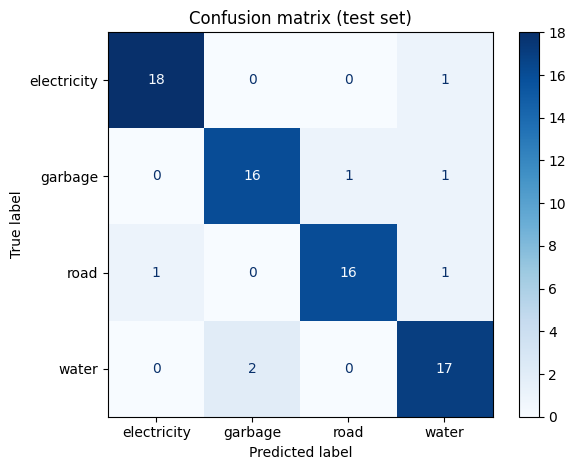

LogReg test accuracy: 0.9594594594594594
NB CV accuracy: mean = 0.9324 std = 0.0476
Saved: complaint_nb_pipeline.joblib (reload with joblib.load)
First 5 features: ['abandon', 'accident', 'accumulate', 'across', 'action']


,electricity,garbage,road,water,predicted,confidence,true
0,0.088939,0.036924,0.823837,0.050300,road,0.823837,road
1,0.452310,0.097147,0.059209,0.391334,electricity,0.452310,electricity
2,0.078589,0.051425,0.220256,0.649730,water,0.649730,water
3,0.640390,0.111301,0.162783,0.085526,electricity,0.640390,electricity
4,0.344923,0.085967,0.355345,0.213764,road,0.355345,road


In [64]:
# Pipeline: TF-IDF fit on train only + Multinomial NB (single object for train / predict / save)
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

_tfidf_params = dict(
    max_features=1500,
    stop_words=None,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    token_pattern=r"(?u)\b[a-z]{2,}\b",
)

pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(**_tfidf_params)),
        ("clf", MultinomialNB(alpha=0.5)),
    ]
)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)
confidence_score = y_proba.max(axis=1)

print("Naive Bayes test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=pipeline.classes_)
disp.plot(values_format="d", cmap="Blues")
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

# Quick benchmark: same TF-IDF settings + logistic regression (often stronger on text)
pipe_lr = Pipeline(
    [("tfidf", TfidfVectorizer(**_tfidf_params)), ("clf", LogisticRegression(max_iter=3000, random_state=42))]
)
pipe_lr.fit(X_train, y_train)
print("LogReg test accuracy:", accuracy_score(y_test, pipe_lr.predict(X_test)))

# 5-fold CV on full data (clone = unfitted; each fold fits only on train fold)
cv_nb = cross_val_score(clone(pipeline), X_text, y, cv=5, scoring="accuracy")
print("NB CV accuracy: mean =", round(cv_nb.mean(), 4), "std =", round(cv_nb.std(), 4))

import joblib

joblib.dump(pipeline, "complaint_nb_pipeline.joblib")
print("Saved: complaint_nb_pipeline.joblib (reload with joblib.load)")

feature_names = pipeline.named_steps["tfidf"].get_feature_names_out()
print("First 5 features:", list(feature_names[:5]))

proba_df = pd.DataFrame(y_proba, columns=pipeline.classes_)
proba_df["predicted"] = y_pred
proba_df["confidence"] = confidence_score
proba_df["true"] = y_test.values
proba_df.head()


In [65]:
# Priority (rule-based) — explicit rules: HIGH > MEDIUM > LOW
import re

# HIGH: danger, risk, accident, fire + phrase "exposed wire" + long "since X days"
_HIGH_WORDS = frozenset({
    "danger",
    "risk",
    "risks",
    "accident",
    "accidents",
    "fire",
    "fires",
})
_LONG_SINCE_DAYS_MIN = 3  # "since X days" counts as HIGH when X >= this

# MEDIUM: overflow, leakage, frequent issue
_MED_WORDS = frozenset({"overflow", "overflowing", "leak", "leakage", "leaking", "frequent"})


def estimate_priority(text: str) -> dict:
    """HIGH / MEDIUM / LOW using your rules; HIGH wins if any HIGH rule matches."""
    if not text or not str(text).strip():
        return {
            "level": "low",
            "score_1_10": 1,
            "raw_score": 0,
            "signals": ["empty text"],
        }

    low = str(text).lower()
    toks = set(re.findall(r"[a-z]{2,}", low))
    signals = []
    high = False

    hit_w = _HIGH_WORDS & toks
    if hit_w:
        high = True
        signals.append("HIGH: " + ", ".join(sorted(hit_w)))

    if "exposed wire" in low:
        high = True
        signals.append('HIGH: phrase "exposed wire"')

    m_since = re.search(r"since\s+(?:the\s+|last\s+|past\s+)?(\d+)\s+days?\b", low)
    if m_since and int(m_since.group(1)) >= _LONG_SINCE_DAYS_MIN:
        high = True
        signals.append(
            f'HIGH: long duration (since {m_since.group(1)} days ≥ {_LONG_SINCE_DAYS_MIN})'
        )

    if high:
        score = min(10, 7 + len(signals))
        return {
            "level": "high",
            "score_1_10": score,
            "raw_score": 10,
            "signals": signals,
        }

    med_signals = []
    hit_m = _MED_WORDS & toks
    if hit_m:
        med_signals.append("MEDIUM: " + ", ".join(sorted(hit_m)))
    if "frequent issue" in low:
        med_signals.append('MEDIUM: phrase "frequent issue"')
    if re.search(r"\bfrequently\b", low) and "frequent issue" not in low:
        med_signals.append("MEDIUM: frequently")

    if med_signals:
        return {
            "level": "medium",
            "score_1_10": 5,
            "raw_score": 5,
            "signals": med_signals,
        }

    return {
        "level": "low",
        "score_1_10": 2,
        "raw_score": 1,
        "signals": ["LOW: general complaint (no HIGH/MEDIUM rules matched)"],
    }


_pri_col = df["complaint"].map(estimate_priority)
df["priority_level"] = _pri_col.map(lambda x: x["level"])
df["priority_1_10"] = _pri_col.map(lambda x: x["score_1_10"])
df[["complaint", "category", "priority_level", "priority_1_10"]].head(8)


,complaint,category,priority_level,priority_1_10
0,The road in front of our colony has been full ...,road,low,2
1,There has been no water supply in our area sin...,water,low,2
2,Power cut is going on continuously for the pas...,electricity,low,2
3,Garbage has not been collected from our street...,garbage,low,2
4,The main road near the bus stop is completely ...,road,high,8
5,Tap water supply has been completely dry in ou...,water,low,2
6,Lights on our street have not been working for...,electricity,low,2
7,Trash bins near the park are overflowing and n...,garbage,medium,5


In [66]:
# Custom inputs — must use the SAME pipeline as training (raw text -> cleaned_complaint)
# Skipping that step was why "electrical wires ... near market" looked like "road" (shared words: near, market, ...)
import re


def preprocess_raw_complaint(raw: str) -> str:
    """Match df: lower -> strip punctuation -> _remove_stopwords -> _lemmatize_text."""
    s = str(raw).strip().lower()
    s = re.sub(r"[^\w\s]+", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = _remove_stopwords(s)
    s = _lemmatize_text(s)
    return s


test_complaints = [
    "Water supply has been interrupted for two days and no help has arrived.",
    "Electrical wires are hanging loose near our market and pose a danger.",
    "Garbage has not been collected from the street and the bins are overflowing.",
]

test_cleaned = [preprocess_raw_complaint(t) for t in test_complaints]
test_pred = pipeline.predict(test_cleaned)
test_proba = pipeline.predict_proba(test_cleaned)
test_confidence = test_proba.max(axis=1)

for i, complaint in enumerate(test_complaints):
    pri = estimate_priority(complaint)
    print(f"\nComplaint: {complaint}")
    print(f"After same cleaning as training: {test_cleaned[i]!r}")
    print(
        f"Predicted Category: {test_pred[i]} (Confidence: {test_confidence[i]:.4f})"
    )
    print(
        f"Priority: {pri['level'].upper()} ({pri['score_1_10']}/10) — rule-based, not from ML"
    )
    if pri["signals"]:
        print("  Why:", "; ".join(pri["signals"]))


Complaint: Water supply has been interrupted for two days and no help has arrived.
After same cleaning as training: 'water supply interrupt two day no help arrive'
Predicted Category: water (Confidence: 0.8744)
Priority: LOW (2/10) — rule-based, not from ML
  Why: LOW: general complaint (no HIGH/MEDIUM rules matched)

Complaint: Electrical wires are hanging loose near our market and pose a danger.
After same cleaning as training: 'electrical wire hang loose near market pose danger'
Predicted Category: electricity (Confidence: 0.5466)
Priority: HIGH (8/10) — rule-based, not from ML
  Why: HIGH: danger

Complaint: Garbage has not been collected from the street and the bins are overflowing.
After same cleaning as training: 'garbage not collect street bin overflow'
Predicted Category: garbage (Confidence: 0.8501)
Priority: MEDIUM (5/10) — rule-based, not from ML
  Why: MEDIUM: overflowing
